In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

pd.options.display.max_columns = None

In [24]:
train_data = pd.read_parquet(r"E:\E2E Project 1\E2E-Project-1\fraud-detection-ml\data\parquet\train_data_merged.parquet")
train_data.shape

(590540, 434)

In [25]:
train_data['TransactionID'].nunique() == train_data.shape[0]

True

In [26]:
pd.Series(train_data.dtypes.values).value_counts()   # Diff types of features

float64    399
object      31
int64        4
Name: count, dtype: int64

In [27]:
print( train_data['isFraud'].value_counts())
print(train_data['isFraud'].value_counts()/train_data.shape[0])

isFraud
0    569877
1     20663
Name: count, dtype: int64
isFraud
0    0.96501
1    0.03499
Name: count, dtype: float64


In [28]:
missing_summary = (
    train_data.isnull().mean()
    .reset_index()
    .rename(columns={"index": "feature", 0: "missing_ratio"})
    .sort_values("missing_ratio", ascending=False)
)

missing_summary[missing_summary["missing_ratio"] > 0.8]

,feature,missing_ratio
417,id_24,0.991962
418,id_25,0.991310
400,id_07,0.991271
401,id_08,0.991271
414,id_21,0.991264
...,...,...
393,V339,0.860550
389,V335,0.860550
391,V337,0.860550
382,V328,0.860550


In [29]:
cat_columns = train_data.select_dtypes(include='object').columns
print(len(cat_columns) )
missing_summary[missing_summary['feature'].isin(cat_columns)]

31


,feature,missing_ratio
420,id_27,0.991247
416,id_23,0.991247
426,id_33,0.875895
423,id_30,0.868654
427,id_34,0.868248
433,DeviceInfo,0.799055
409,id_16,0.780980
16,R_emaildomain,0.767516
424,id_31,0.762451
432,DeviceType,0.761557


In [30]:
missing_summary[missing_summary["missing_ratio"] > 0.8].to_csv('dropped_features.csv',index=False)

In [31]:
train_data = train_data.drop(columns=missing_summary[missing_summary["missing_ratio"] > 0.8]['feature'].values)
train_data.shape

(590540, 360)

In [32]:
train_data.isna().sum().sum()

np.int64(76930261)

In [ ]:
# from sklearn.base import BaseEstimator, TransformerMixin
# from sklearn.impute import SimpleImputer
# import pandas as pd

# class DataFrameImputer(BaseEstimator, TransformerMixin):
#     """Imputer that properly handles pandas DataFrames"""
    
#     def __init__(self, num_strategy='median', cat_strategy='most_frequent'):
#         self.num_strategy = num_strategy
#         self.cat_strategy = cat_strategy
#         self.num_imputer = None
#         self.cat_imputer = None
#         self.num_columns = None
#         self.cat_columns = None
    
#     def fit(self, X, y=None):
#         self.num_columns = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
#         self.cat_columns = X.select_dtypes(include=['object']).columns.tolist()
        
#         if self.num_columns:
#             self.num_imputer = SimpleImputer(strategy=self.num_strategy)
#             self.num_imputer.fit(X[self.num_columns])
        
#         if self.cat_columns:
#             self.cat_imputer = SimpleImputer(strategy=self.cat_strategy)
#             self.cat_imputer.fit(X[self.cat_columns])
        
#         return self
    
#     def transform(self, X):
#         X_copy = X.copy()
        
#         if self.num_columns and self.num_imputer:
#             num_imputed = self.num_imputer.transform(X_copy[self.num_columns])
#             for i, col in enumerate(self.num_columns):
#                 X_copy.loc[:, col] = num_imputed[:, i]
        
#         if self.cat_columns and self.cat_imputer:
#             cat_imputed = self.cat_imputer.transform(X_copy[self.cat_columns])
#             for i, col in enumerate(self.cat_columns):
#                 X_copy.loc[:, col] = cat_imputed[:, i]
        
#         return X_copy

After using Simple Imputer and converting it back to Pandas Dataframe, throws error

In [ ]:
# from sklearn.impute import SimpleImputer

# num_cols = train_data.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
# cat_cols = train_data.select_dtypes(include=['object']).columns.tolist()

# print(len(num_cols), len(cat_cols))
# print(train_data.shape)
# print('Null values in numeric columns:', train_data[num_cols].isna().sum().sum())
# print('Null values in categorical columns:', train_data[cat_cols].isna().sum().sum())
# print('Total null values:', train_data.isna().sum().sum())
# num_imputer = SimpleImputer(strategy='median')
# cat_imputer = SimpleImputer(strategy='most_frequent', fill_value='missing')

# num_data_cleaned = num_imputer.fit_transform(train_data[num_cols])
# cat_data_cleaned = cat_imputer.fit_transform(train_data[cat_cols])

# print('Numeric data shape:', num_data_cleaned.shape, 'data type:', type(num_data_cleaned))
# print('Categorical data shape:', cat_data_cleaned.shape, 'data type:', type(cat_data_cleaned))
# print('Null values in numeric data:', np.isnan(num_data_cleaned).sum())
# # print('Null values in categorical data:', np.isnan(cat_data_cleaned).sum())

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# Custom transformer that works properly with DataFrames
from sklearn.base import BaseEstimator, TransformerMixin

class DataFrameImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.fill_values = {}
    
    def fit(self, X, y=None):
        for col in X.columns:
            if X[col].dtype in ['int64', 'float64', 'int32', 'float32']:
                self.fill_values[col] = X[col].median()
            else:
                fill_val = 'Missing'
                self.fill_values[col] = fill_val
        return self
    
    def transform(self, X):
        return X.fillna(self.fill_values)

# Use it in a pipeline
pipeline = Pipeline([
    ('imputer', DataFrameImputer()),
])

print(train_data.shape,'Null values before:', train_data.isna().sum().sum())
train_data_cleaned = pipeline.named_steps['imputer'].fit_transform(train_data)
print(train_data_cleaned.shape,'Null values after:', train_data_cleaned.isna().sum().sum())

(590540, 360) Null values before: 76930261
(590540, 360) Null values after: 0


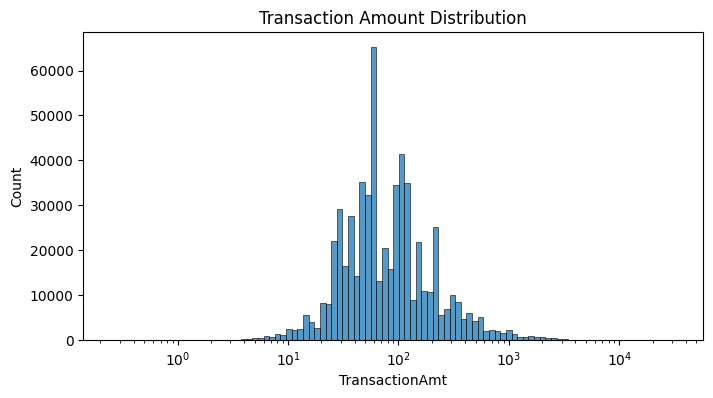

In [15]:
plt.figure(figsize=(8, 4))
sb.histplot(train_data["TransactionAmt"], bins=100, log_scale=(True, False))
plt.title("Transaction Amount Distribution")
plt.show()

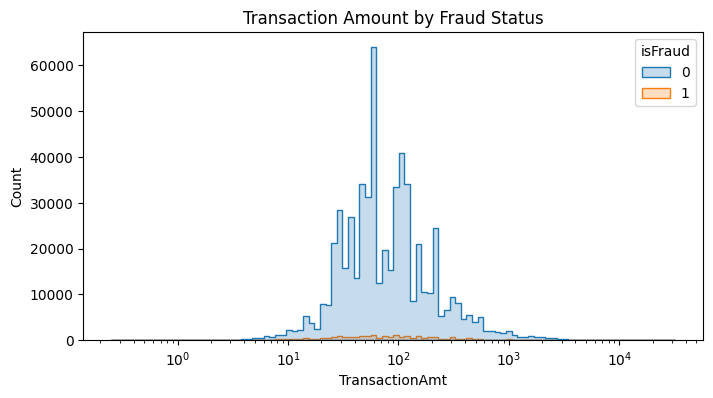

In [16]:
# Fraud vs Non-Fraud comparison
plt.figure(figsize=(8, 4))
sb.histplot(data=train_data, x="TransactionAmt", hue='isFraud', bins=100, log_scale=(True, False), element="step")
plt.title("Transaction Amount by Fraud Status")
plt.show()

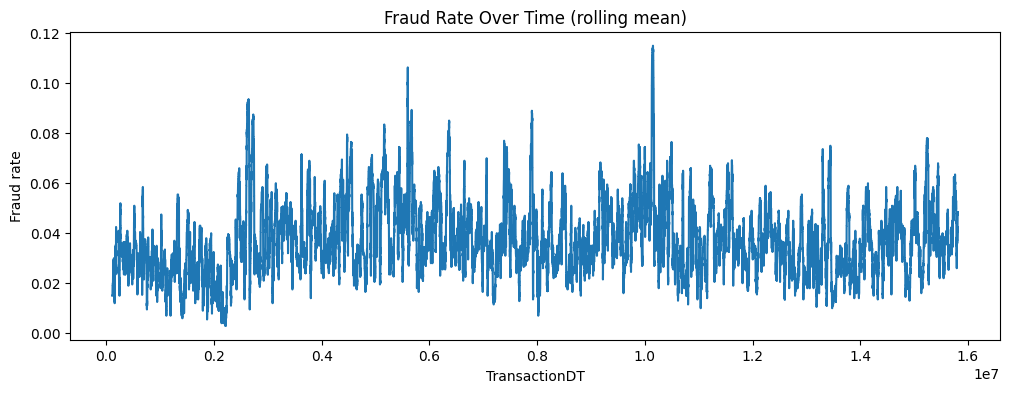

In [17]:
# TransactionDT (time feature)
if "TransactionDT" in train_data.columns:
    plt.figure(figsize=(12, 4))
    train_data.groupby("TransactionDT")['isFraud'].mean().rolling(1000).mean().plot()
    plt.title("Fraud Rate Over Time (rolling mean)")
    plt.ylabel("Fraud rate")
    plt.show()


Fraud rate by ProductCD:
 ProductCD
C    0.116873
S    0.058996
H    0.047662
R    0.037826
W    0.020399
Name: isFraud, dtype: float64


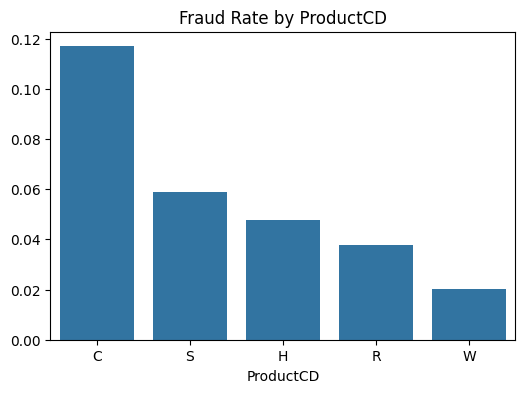

In [18]:
if "ProductCD" in train_data.columns:
    fraud_rate_product = train_data.groupby("ProductCD")['isFraud'].mean().sort_values(ascending=False)
    print("\nFraud rate by ProductCD:\n", fraud_rate_product)

    plt.figure(figsize=(6, 4))
    sb.barplot(x=fraud_rate_product.index, y=fraud_rate_product.values)
    plt.title("Fraud Rate by ProductCD")
    plt.show()


Fraud rate by Card4:
 card4
discover            0.077282
visa                0.034756
mastercard          0.034331
american express    0.028698
Name: isFraud, dtype: float64


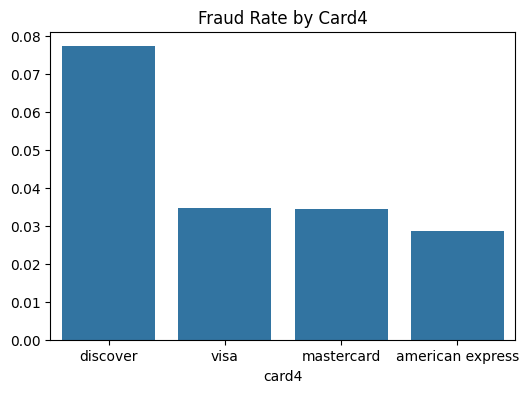

In [19]:
if "card4" in train_data.columns:
    fraud_rate_card4 = train_data.groupby("card4")['isFraud'].mean().sort_values(ascending=False)
    print("\nFraud rate by Card4:\n", fraud_rate_card4)

    plt.figure(figsize=(6, 4))
    sb.barplot(x=fraud_rate_card4.index, y=fraud_rate_card4.values)
    plt.title("Fraud Rate by Card4")
    plt.show()

In [ ]:
# numeric_cols = train_data.select_dtypes(include=["float64", "int64"]).columns
# corr = train_data[numeric_cols].corr()[['isFraud']].sort_values('isFraud', ascending=False)

# print("\nTop 10 features correlated with target:")
# print(corr.head(10))

# plt.figure(figsize=(6, 12))
# sb.heatmap(corr.head(20), annot=True, cmap="coolwarm", center=0)
# plt.title("Top Correlations with Fraud")
# plt.show()

In [36]:
train_data.isna().sum().sum()

np.int64(76930261)

In [34]:
train_data_cleaned.isna().sum().sum()

np.int64(0)

In [37]:
train_data_cleaned.shape

(590540, 360)

In [35]:
train_data_cleaned.to_parquet(r"E:\E2E Project 1\E2E-Project-1\fraud-detection-ml\data\parquet\train_data_cleaned.parquet", index=False)